In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

import yfinance as yf

In [2]:
data = yf.download('AAPL', start='2015-01-01', end='2023-01-01')

df = data[['Close']]
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.192602
2015-01-05,23.511059
2015-01-06,23.513275
2015-01-07,23.842978
2015-01-08,24.759081


In [3]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

In [4]:
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

In [5]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [6]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [7]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

c:\Users\prach\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [9]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32
)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0049
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.5602e-04
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 2.8922e-04
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.7985e-04
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.6036e-04
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.5013e-04
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.6396e-04
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.5038e-04
Epoch 9/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 2.4014e-04
Epoch 10/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 2.7573e-04


In [10]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


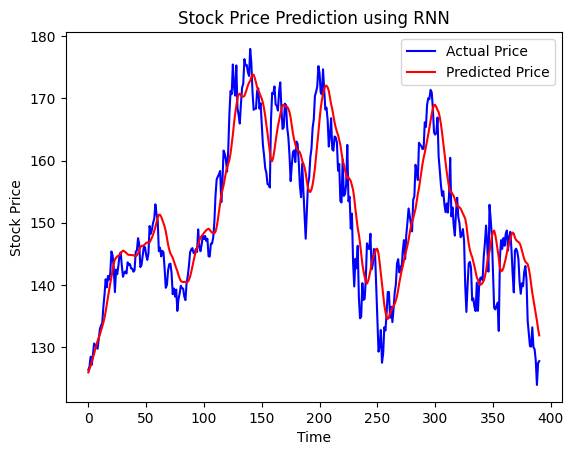

In [11]:
plt.plot(y_test_actual, color='blue', label='Actual Price')
plt.plot(predictions, color='red', label='Predicted Price')

plt.title("Stock Price Prediction using RNN")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.show()

In [12]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_actual, predictions)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

MSE: 27.209413940101847
RMSE: 5.216264366393046
